# Compulsory assignment
***Sara Alida Bakkebø (s-number) & Peter Tveita (251819)***
***

## Task 1
***

In [52]:
#Importing starter code 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

np.random.seed(123)

data = pd.read_csv("day.csv")

X = data.drop(columns=["cnt"])
y = data["cnt"]

data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [53]:
#Statistics of cnt
print(data['cnt'].describe())

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64


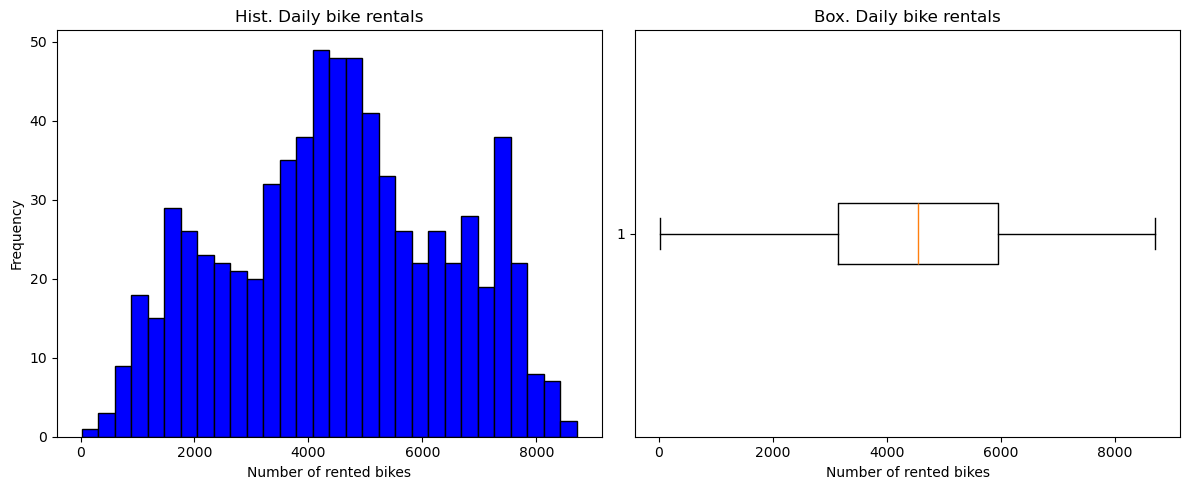

Correlation with cnt
cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64


In [54]:
#Graphs to vizualise cnt
plt.figure(figsize=(12,5))

#Histogram
plt.subplot(1,2,1)
plt.hist(data['cnt'], bins=30, color ='blue', edgecolor='black')
plt.title('Hist. Daily bike rentals')
plt.xlabel('Number of rented bikes')
plt.ylabel('Frequency')

#Boxplot to show summary of distribution
plt.subplot(1,2,2)
plt.boxplot(data['cnt'], vert=False)
plt.title('Box. Daily bike rentals')
plt.xlabel('Number of rented bikes')

plt.tight_layout()
plt.show()

#Correlation matrix
correlation = data.corr(numeric_only=True)['cnt'].sort_values(ascending=False)
print('Correlation with cnt')
print(correlation)


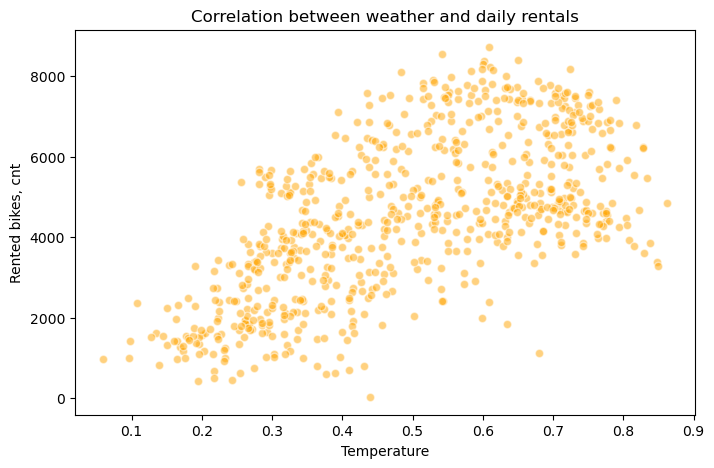

In [55]:
#After looking at the correlation we see that atemp has a high correlation to cnt
#We choose to make a scatterplot to the strongest promising predictor
plt.figure(figsize=(8,5))
plt.scatter(data['temp'],data['cnt'],alpha=0.5, color='orange', edgecolor='white')
plt.title('Correlation between weather and daily rentals')
plt.xlabel('Temperature')
plt.ylabel('Rented bikes, cnt')
plt.show()


In [56]:
#Removing the variables not available at the time of prediction, or that are purely administrative
drop_list = ['cnt','casual','registered','temp','instant','dteday']

X = data.drop(columns=drop_list)
y = data['cnt']

print(X.columns.tolist())
print(f'Numbers of predictors in X: {X.shape[1]}')



['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed']
Numbers of predictors in X: 10


#### Interpretation

The variables 'registered' and 'casual' were removed as they directly sum to the response variable cnt, which would result in data leakage. 'instand' and 'dteday' are administrative variables and were removed as they do not provide predictive information. 
The varibles 'atempt and 'temp' are highly correlated, and to avoid multicollinearity only 'atemp' was retained in the analysis. 

## Task 2
***

In [57]:
# We choose to split train 75%, and test 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

print(f'Training observations: {X_train.shape[0]}')
print(f'Test observations: {X_test.shape[0]}')

Training observations: 548
Test observations: 183


In [58]:
#Creating and training the model on the training set
model = LinearRegression()
model.fit(X_train,y_train)

#Making predictions on the test data
y_pred = model.predict(X_test)

#Calculating margins of error to evaluate performance, using MSE
mse = np.mean((y_test-y_pred)**2)
sq_mse = np.sqrt(mse)

print(f'Test MSE: {mse:.2f}')


Test MSE: 868468.77


In [59]:
#Polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

#Creating polynomial variables
poly=PolynomialFeatures(degree = 2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Training new linear model on transformed data
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

#Making predictions and calculating errors
y_pred_poly = poly_model.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f'Polynomial test MSE: {mse_poly:.2f}')

Polynomial test MSE: 515770.76


In [60]:
#Results to compare:
print(f'Test MSE: {mse:.2f}')
print(f'Polynomial test MSE: {mse_poly:.2f}', end='\n\n')

#Results of squared MSE to see daily errors:
rmse = np.sqrt(mse)
print(f'Test RMSE: {rmse:.2f}')

poly_rmse = np.sqrt(mse_poly)
print(f'Polynomial Test RMSE: {poly_rmse:.2f}')

Test MSE: 868468.77
Polynomial test MSE: 515770.76

Test RMSE: 931.92
Polynomial Test RMSE: 718.17


## Task 3
***

In [61]:
n = len(X)
MSE1 = np.zeros(n)
MSE2 = np.zeros(n)

for i in range (n):
    #leaving out observation i
    X_train = X.drop(index=i)
    X_test = X.iloc[[i]]
    y_train = y.drop(index=i)
    y_test = y.iloc[i]

    #model1:
    mod1=LinearRegression()
    mod1.fit(X_train, y_train)
    pred1 = mod1.predict(X_test)[0]

    #model 2:
    poly1 = poly=PolynomialFeatures(degree = 2, include_bias=False)
    X_train_poly1 = poly1.fit_transform(X_train)
    X_test_poly1 = poly1.transform(X_test)

    mod2 = LinearRegression()
    mod2.fit(X_train_poly1, y_train)
    pred2 = mod2.predict(X_test_poly1)[0]

    MSE1[i]=(y_test - pred1)**2
    MSE2[i]=(y_test - pred2)**2

#LOOVC estimates
loo_mse_lin = MSE1.mean()
loo_mse_poly = MSE2.mean()

print(f'LOOCV MSE for linear model {loo_mse_lin:.2f}')
print(f'LOOCV MSE for polynomial model {loo_mse_poly:.2f}')
    

LOOCV MSE for linear model 778521.70
LOOCV MSE for polynomial model 578920.89


#### Interpretation

Using LOOVC validation, we see that the polynomial model has the lowest mean sqaure error, indicating a better predictive outcome. Leave-one-out cross-validation estimates the test error by leaving one observation out at a time, traning the model on the remaining data, with the remaning observation as the prediction.

The validation is consistent with the validation from Task 2, where the polynomial model also achieved the lowest MSE. This suggests that the model is consistent, and not sensitive to the data-split.

## Task 4

Using the Pipeline from the task:
***

In [62]:
#Determination of K, from task
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

#Define 10-fold cross-validation
cv = KFold(n_splits = 10, shuffle = True, random_state = 1)

#Range of values for K to test
Ks = range(1, 41)
cv_mse = []

#Loop over all values of K
for k in Ks:
    pipe.set_params(knn__n_neighbors = k) #Number of neighbors
    fold_errors = []

    #10-fold cross-validation for k
    for train_idx, test_idx in cv.split(X):
        
        #Split data into training and testing
        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        #Fit model on training data
        pipe.fit(X_train_cv, y_train_cv)
        y_pred = pipe.predict(X_test_cv)
        
        #Compute MSE for iteration k
        fold_errors.append(np.mean((y_test_cv - y_pred)**2))

    #Store mean CV MSE for iteration k
    cv_mse.append(np.mean(fold_errors))

#Locate K with min CV error
best_k = Ks[np.argmin(cv_mse)]

print("Best K:", best_k)
print("Lowest CV MSE:", min(cv_mse))

Best K: 5
Lowest CV MSE: 712714.0704487228


In [63]:
#Create KNN model using best K
knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors = best_k))
])

knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

In [64]:
#Compute MSE and RMSE for KNN
mse_knn = np.mean((y_test - y_pred_knn)**2)
rmse_knn = np.sqrt(mse_knn)

print(f"KNN test MSE: {mse_knn:,.2f}".replace(",", " ")) #Formatting to thousand-seperator 
print(f"KNN test RMSE: {rmse_knn:,.2f}".replace(",", " "))

KNN test MSE: 674 041.00
KNN test RMSE: 821.00


In [65]:
#Compare with linear and polynomial model
print(f"Linear test MSE: {mse:,.2f}".replace(",", " "))
print(f"Polynomial test MSE: {mse_poly:,.2f}".replace(",", " "))
print(f"KNN test MSE: {mse_knn:,.2f}".replace(",", " "))

Linear test MSE: 868 468.77
Polynomial test MSE: 515 770.76
KNN test MSE: 674 041.00


#### Interpretation

As the model measures distance between observations, the variables were standardized using the given pipeline from the task. This is to ensure that all variables contribute equally to the calculations. 

The parameter K was selected using 10-fold cross-validation. This divides the dataset into 10 equally sized subsets, training the model on all 9 other folds for each value of K. This process is repeated 10 times, once for each fold. The mean MSE was then computed, locating the value of K giving the lowest mean squared error, which was $K = 5$. The model was then evaluated on a seperate test set, avoiding using the data from cross-validation.

This gave a lower MSE than linear regression, but higher than polynomial regression, suggesting that the data may be non-linear. The polynomial model achieves a better MSE than the KNN model, as it is more flexible and better captures nonlinear relationships, whereas the KNN relies on local averages, making it more prone to noise in the data.

## Task 5

***

As the linear model achieves higher MSE than both the KNN and polynomial model, we can argue that the relationship between `cnt` and predictor variables such as `temp` is not purely linear. This is logical, as moderate temperatures may increase daily bike rentals, whilst both very high and low temperatures may reduce rentals, indicating a nonlinear relationship. This also suggests the idea that `cnt` does not rely on one predictor alone, but a combination of variables. 

In [66]:
#Fitting a more flexible model: Regression tree

#Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.5, random_state = 132
)

#Initialize tree
tree = DecisionTreeRegressor(random_state = 1)

#Fit data with training data
tree.fit(X_train, y_train)

#Predict using test data
y_pred_tree = tree.predict(X_test)

#Compute MSE
mse_tree = np.mean((y_test - y_pred_tree)**2)

print(f"Regression tree test MSE: {mse_tree:,.2f}".replace(",", " "))

Regression tree test MSE: 918 177.45


#### Interpretation

Although regression trees are flexible and capture nonlinear relations between variables, the model achieves a higher MSE than the previous models. This may suggest overfitting and high variance of the regression tree, leading to poor generalization on the test data. This demonstrates the bias-variance tradeoff, where the flexibility of the model also allows it to capture noise. As a result, the model may fail to capture the underlying pattern, leading to unstable predictions. Compared to smoother models such as GAM, the stepwise nature of the regression tree may also miss the gradual effects that occur in the number of daily bike rentals.

We reused the split from task 2 to divide the dataset into a training and a test set. The model was fitted on the training set and evaluated on the test set.